# PraProses pada data

## mengambil data sekunder rekomendasi olahraga

### Impor data sekunder

In [2]:
import kagglehub

path = kagglehub.dataset_download("valakhorasani/gym-members-exercise-dataset")

print("Path to dataset files:", path)

100%|██████████| 21.6k/21.6k [00:00<00:00, 33.4MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/valakhorasani/gym-members-exercise-dataset/versions/1


### Cek konten data mentah

In [3]:
!ls "/root/.cache/kagglehub/datasets/valakhorasani/gym-members-exercise-dataset/versions/1"

gym_members_exercise_tracking.csv


### Pengambilan data dalam 1 frame

In [4]:
import pandas as pd

df = pd.read_csv("/root/.cache/kagglehub/datasets/valakhorasani/gym-members-exercise-dataset/versions/1/gym_members_exercise_tracking.csv")

df

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,Male,87.1,1.74,187,158,67,1.57,1364.0,Strength,10.0,3.5,4,3,28.77
969,25,Male,66.6,1.61,184,166,56,1.38,1260.0,Strength,25.0,3.0,2,1,25.69
970,59,Female,60.4,1.76,194,120,53,1.72,929.0,Cardio,18.8,2.7,5,3,19.50
971,32,Male,126.4,1.83,198,146,62,1.10,883.0,HIIT,28.2,2.1,3,2,37.74


## cek konten secara detail

In [5]:
jumlah_data = len(df)
jumlah_fitur = len(df.columns)

print(f"jumlah data terdapat : {jumlah_data}")
print(f"jumlah fitur pada data terdapat: {jumlah_fitur}")

jumlah data terdapat : 973
jumlah fitur pada data terdapat: 15


### bagi tipe data dari dataframe

In [6]:
from pandas.api.types import is_numeric_dtype, is_bool_dtype, is_string_dtype, is_categorical_dtype

def is_numeric_boolean(feature):
  unique_value = feature.dropna().unique()
  return set(unique_value).issubset({0, 1})


def categorize_features(df, id_threshold= 0.95, cat_unique_thres=0.05):
  n = len(df)
  result = {
      "numeric" : [],
      "boolean" : [],
      "categorical": [],
      "identifier": []
  }
  for col in df.columns:
    feature = df[col]
    dtype = feature.dtype

    if is_bool_dtype(feature) or is_numeric_boolean(feature):
      result["boolean"].append(col)

    elif is_numeric_dtype(feature):
      num_unique = feature.nunique(dropna=True)
      if num_unique / n > id_threshold:
        result["identifier"].append(col)
      else:
        result["numeric"].append(col)

    elif is_categorical_dtype(feature) or is_string_dtype(feature):
      num_unique = feature.nunique(dropna=True)
      if num_unique / n > id_threshold:
        result["identifier"].append(col)
      elif num_unique / n < cat_unique_thres:
        result["categorical"].append(col)
      else:
        result["categorical"].append(col)
  return result

### Bagi seluruh tipe data dari dataframe

In [7]:
dictionary = categorize_features(df)
for key, cols in dictionary.items():
    print(f"\n{key.upper()} ({len(cols)} features):")
    for col in cols:
        print(f"  - {col}")


NUMERIC (13 features):
  - Age
  - Weight (kg)
  - Height (m)
  - Max_BPM
  - Avg_BPM
  - Resting_BPM
  - Session_Duration (hours)
  - Calories_Burned
  - Fat_Percentage
  - Water_Intake (liters)
  - Workout_Frequency (days/week)
  - Experience_Level
  - BMI

BOOLEAN (0 features):

CATEGORICAL (2 features):
  - Gender
  - Workout_Type

IDENTIFIER (0 features):


/tmp/ipython-input-3397107932.py:30: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif is_categorical_dtype(feature) or is_string_dtype(feature):


### melihat jumlah jenis pada variabel `dependent`

In [8]:
value_counts = df["Workout_Type"].value_counts(dropna=False)
print("Semua hasil unik dari Workout_Type sebelum hapus outlier dan missing values: \n")
print(value_counts)

Semua hasil unik dari Workout_Type sebelum hapus outlier dan missing values: 

Workout_Type
Strength    258
Cardio      255
Yoga        239
HIIT        221
Name: count, dtype: int64


### Hapus record jika ada `outlier` ataupun `missing values`

In [9]:
import numpy as np

missing_mask = df.isnull()
print("\nMissing values:\n", missing_mask.sum())

def detect_outliers_iqr(df):
    outlier_mask = pd.DataFrame(False, index=df.index, columns=df.columns)
    for col in df.select_dtypes(include=[np.number]):
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outlier_mask[col] = (df[col] < lower) | (df[col] > upper)
    return outlier_mask

outlier_mask = detect_outliers_iqr(df)
print("\nOutliers detected:\n", outlier_mask.sum())

combined_mask = missing_mask.any(axis=1) | outlier_mask.any(axis=1)

new_df = df[~combined_mask].reset_index(drop=True)

print("\nCleaned DataFrame (X):")
new_df



Missing values:
 Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64

Outliers detected:
 Age                               0
Gender                            0
Weight (kg)                       9
Height (m)                        0
Max_BPM                           0
Avg_BPM                           0
Resting_BPM                       0
Session_Duration (hours)          0
Calories_Burned                  10
Workout_Type                      0
Fat_Percentage                    0
Water_Intake (liters)      

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
927,24,Male,87.1,1.74,187,158,67,1.57,1364.0,Strength,10.0,3.5,4,3,28.77
928,25,Male,66.6,1.61,184,166,56,1.38,1260.0,Strength,25.0,3.0,2,1,25.69
929,59,Female,60.4,1.76,194,120,53,1.72,929.0,Cardio,18.8,2.7,5,3,19.50
930,32,Male,126.4,1.83,198,146,62,1.10,883.0,HIIT,28.2,2.1,3,2,37.74


In [10]:
df = new_df
X = df.drop("Workout_Type", axis = 1)
y = df["Workout_Type"]

In [11]:
value_counts = df["Workout_Type"].value_counts(dropna=False)
print("Semua hasil unik dari Workout_Type setelah hapus outlier dan missing value: \n")
print(value_counts)

Semua hasil unik dari Workout_Type setelah hapus outlier dan missing value: 

Workout_Type
Strength    246
Cardio      245
Yoga        231
HIIT        210
Name: count, dtype: int64


## Data cleaning pada categorical

In [12]:
from sklearn.preprocessing import LabelEncoder
df_categorical = X["Gender"]

encoder = LabelEncoder()
df_categorical_encoded = encoder.fit_transform(df_categorical)


print("Class order:", encoder.classes_)

df_categorical_encoded = pd.DataFrame(df_categorical_encoded, columns=["Gender_Encoded"], index=df_categorical.index)



# 0 - perempuan
# 1 - laki laki

Class order: ['Female' 'Male']


In [13]:
df_categorical_encoded.head()

,Gender_Encoded
0,1
1,0
2,0
3,1
4,1


In [14]:
df_categorical.head()

,Gender
0,Male
1,Female
2,Female
3,Male
4,Male


In [15]:
from sklearn.preprocessing import LabelEncoder


encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

y_encoded= pd.DataFrame(y_encoded, columns=["WorkOutType_Encoded_Train"], index=y.index)

# 0 - cardio
# 1 - HIIT
# 2 - strength
# 3 - yoga

In [16]:
y.head()

,Workout_Type
0,Yoga
1,HIIT
2,Cardio
3,Strength
4,Strength


In [17]:
y_encoded.head()

,WorkOutType_Encoded_Train
0,3
1,1
2,0
3,2
4,2


## Data cleaning pada tipe data numerical

In [18]:
df_numerical = X.drop("Gender", axis = 1)
df_numerical.head()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,88.3,1.71,180,157,60,1.69,1313.0,12.6,3.5,4,3,30.20
1,46,74.9,1.53,179,151,66,1.30,883.0,33.9,2.1,4,2,32.00
2,32,68.1,1.66,167,122,54,1.11,677.0,33.4,2.3,4,2,24.71
3,25,53.2,1.70,190,164,56,0.59,532.0,28.8,2.1,3,1,18.41
4,38,46.1,1.79,188,158,68,0.64,556.0,29.2,2.8,3,1,14.39


In [19]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

scaler = MinMaxScaler()

df_numerical_scaled = pd.DataFrame(
    scaler.fit_transform(df_numerical),
    columns=df_numerical.columns,
    index=df_numerical.index
)

df_numerical_scaled.head()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,0.926829,0.552000,0.42,0.512821,0.755102,0.416667,0.798658,0.779923,0.104,0.909091,0.666667,1.0,0.622780
1,0.682927,0.398857,0.06,0.487179,0.632653,0.666667,0.536913,0.447876,0.956,0.272727,0.666667,0.5,0.685475
2,0.341463,0.321143,0.32,0.179487,0.040816,0.166667,0.409396,0.288803,0.936,0.363636,0.666667,0.5,0.431557
3,0.170732,0.150857,0.40,0.769231,0.897959,0.250000,0.060403,0.176834,0.752,0.272727,0.333333,0.0,0.212121
4,0.487805,0.069714,0.58,0.717949,0.775510,0.750000,0.093960,0.195367,0.768,0.590909,0.333333,0.0,0.072100


## Hasil akhir cleaning data untuk training

In [20]:
X_cleaned = pd.concat([df_numerical_scaled, df_categorical_encoded], axis=1)

X_cleaned.head()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Gender_Encoded
0,0.926829,0.552000,0.42,0.512821,0.755102,0.416667,0.798658,0.779923,0.104,0.909091,0.666667,1.0,0.622780,1
1,0.682927,0.398857,0.06,0.487179,0.632653,0.666667,0.536913,0.447876,0.956,0.272727,0.666667,0.5,0.685475,0
2,0.341463,0.321143,0.32,0.179487,0.040816,0.166667,0.409396,0.288803,0.936,0.363636,0.666667,0.5,0.431557,0
3,0.170732,0.150857,0.40,0.769231,0.897959,0.250000,0.060403,0.176834,0.752,0.272727,0.333333,0.0,0.212121,1
4,0.487805,0.069714,0.58,0.717949,0.775510,0.750000,0.093960,0.195367,0.768,0.590909,0.333333,0.0,0.072100,1


## Split dataset untuk pelatihan dan pengujian (80 - 20 %)

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_encoded , test_size=0.2, random_state=42, stratify=y)

# Seleksi Fitur

## Filter

### Chi square

In [22]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(score_func=chi2, k='all')


chi2_fit = selector.fit(X_train, y_train)

chi2_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'Chi2_Score': chi2_fit.scores_,
    'p_value': chi2_fit.pvalues_
}).sort_values(by='Chi2_Score', ascending=False)

print(chi2_scores)


                          Feature  Chi2_Score   p_value
11               Experience_Level    1.025448  0.795095
10  Workout_Frequency (days/week)    0.808588  0.847412
8                  Fat_Percentage    0.519849  0.914509
12                            BMI    0.512350  0.916170
5                     Resting_BPM    0.481964  0.922836
3                         Max_BPM    0.456127  0.928419
6        Session_Duration (hours)    0.439036  0.932066
1                     Weight (kg)    0.428189  0.934360
0                             Age    0.334157  0.953482
13                 Gender_Encoded    0.323778  0.955496
9           Water_Intake (liters)    0.244595  0.970088
7                 Calories_Burned    0.236167  0.971550
2                      Height (m)    0.180156  0.980727
4                         Avg_BPM    0.052762  0.996827


In [23]:
selected_features = chi2_scores[chi2_scores["p_value"] < 0.05]["Feature"]
X_train_chi2 = X_train[selected_features]

print("\nSelected Features after Chi-Square:")
print(selected_features.tolist())

print("\nNew DataFrame (X_train_chi2):")
print(X_train_chi2.head())


Selected Features after Chi-Square:
[]

New DataFrame (X_train_chi2):
Empty DataFrame
Columns: []
Index: [542, 518, 258, 219, 587]


### Correlation Coefficient

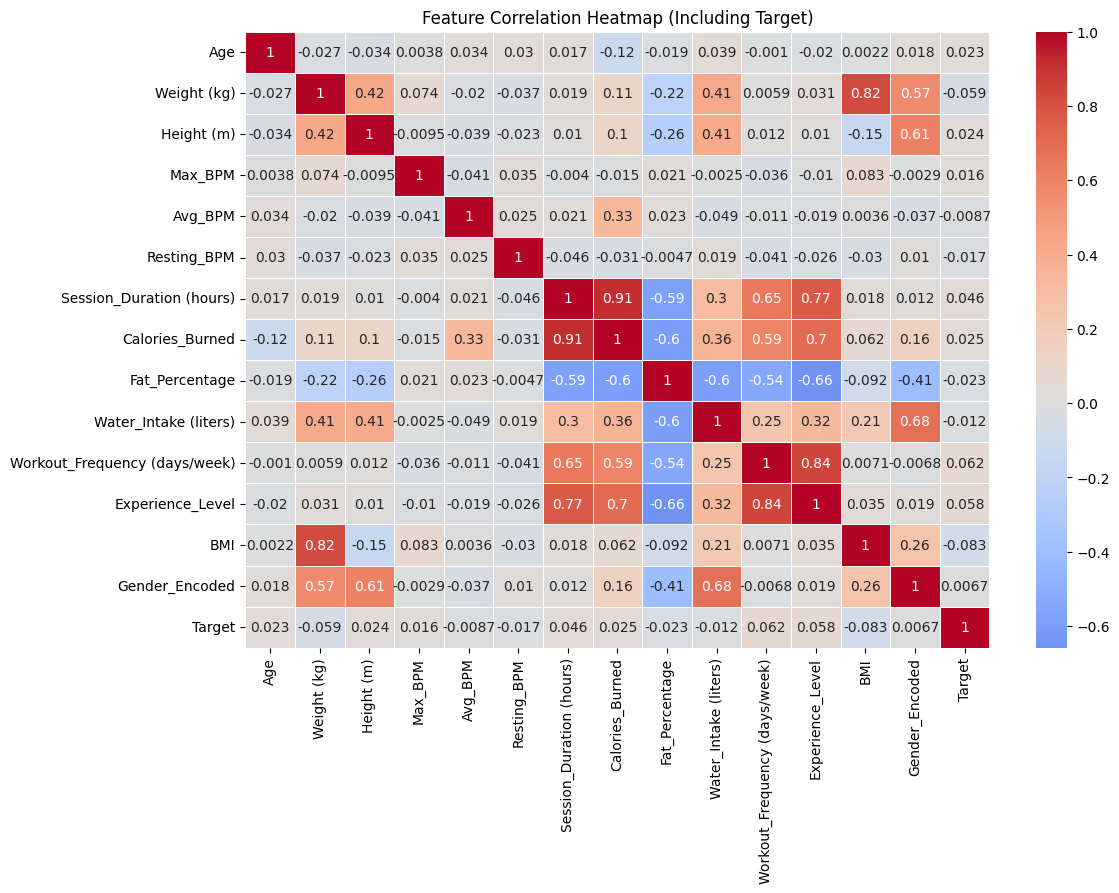

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


y_series = y_train.squeeze().rename('Target')

df_corr = pd.concat([X_train, y_series], axis=1)


corr_matrix = df_corr.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap (Including Target)")
plt.show()

In [25]:
corr_features = X_train.corr().abs()

upper = corr_features.where(np.triu(np.ones(corr_features.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

print("Highly correlated features to drop (r >= 0.9):", to_drop)

X_train_reduced_Correlation_method = X_train.drop(columns=to_drop)

print("\nNew DataFrame after dropping correlated features:")
X_train_reduced_Correlation_method.head()

Highly correlated features to drop (r >= 0.9): ['Calories_Burned']

New DataFrame after dropping correlated features:


,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Gender_Encoded
542,0.512195,0.517714,0.78,0.076923,0.408163,0.458333,0.181208,0.704,0.954545,0.000000,0.0,0.402647,1
518,0.829268,0.296000,0.04,0.717949,0.387755,0.125000,0.516779,0.680,0.363636,0.666667,0.5,0.564263,0
258,0.829268,0.745143,0.24,0.743590,0.428571,0.458333,0.577181,0.704,0.772727,0.333333,0.0,0.967259,1
219,0.243902,0.414857,0.24,0.025641,0.857143,0.833333,0.442953,0.404,0.363636,0.333333,0.5,0.583420,1
587,0.365854,0.156571,0.32,0.794872,0.183673,0.916667,0.503356,0.780,0.454545,0.333333,0.0,0.249739,0


## Wrapper

### RFE

In [26]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression


model = LogisticRegression(max_iter=1000, solver='liblinear')

rfe = RFE(estimator=model, n_features_to_select=10)

rfe.fit(X_train, y_train.values.ravel())

selected_features = X_train.columns[rfe.support_]

X_train_rfe = X_train[selected_features]

print("Selected Features:")
print(selected_features)

print("\nRFE Ranking (1 = Selected):")
rfe_ranking = pd.DataFrame({
    'Feature': X_train.columns,
    'Rank': rfe.ranking_
}).sort_values(by='Rank')



Selected Features:
Index(['Weight (kg)', 'Max_BPM', 'Resting_BPM', 'Session_Duration (hours)',
       'Calories_Burned', 'Fat_Percentage', 'Water_Intake (liters)',
       'Workout_Frequency (days/week)', 'Experience_Level', 'BMI'],
      dtype='object')

RFE Ranking (1 = Selected):


In [27]:
X_train_rfe.head()

,Weight (kg),Max_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
542,0.517714,0.076923,0.458333,0.181208,0.223938,0.704,0.954545,0.000000,0.0,0.402647
518,0.296000,0.717949,0.125000,0.516779,0.379151,0.680,0.363636,0.666667,0.5,0.564263
258,0.745143,0.743590,0.458333,0.577181,0.498842,0.704,0.772727,0.333333,0.0,0.967259
219,0.414857,0.025641,0.833333,0.442953,0.564479,0.404,0.363636,0.333333,0.5,0.583420
587,0.156571,0.794872,0.916667,0.503356,0.388417,0.780,0.454545,0.333333,0.0,0.249739


### backward elimination

In [28]:
import statsmodels.api as sm
import pandas as pd

def backward_elimination(X, y, significance_level=0.05):
    X = sm.add_constant(X)
    while True:
        model = sm.OLS(y, X).fit()
        max_pval = model.pvalues.max()
        if max_pval > significance_level:
            excluded_feature = model.pvalues.idxmax()
            print(f"Removing '{excluded_feature}' (p={max_pval:.4f})")
            X = X.drop(columns=excluded_feature)
        else:
            break
    return X.columns, model

selected_columns, final_model = backward_elimination(X_train, y_train.values)

print("\n Final Selected Features:")
print(selected_columns)

Removing 'Resting_BPM' (p=0.6650)
Removing 'Fat_Percentage' (p=0.6470)
Removing 'Experience_Level' (p=0.5422)
Removing 'Max_BPM' (p=0.4651)
Removing 'Weight (kg)' (p=0.4391)
Removing 'Height (m)' (p=0.8397)
Removing 'Age' (p=0.2570)
Removing 'Water_Intake (liters)' (p=0.1926)
Removing 'Workout_Frequency (days/week)' (p=0.2284)
Removing 'Avg_BPM' (p=0.1410)
Removing 'Gender_Encoded' (p=0.2444)
Removing 'Calories_Burned' (p=0.3794)
Removing 'Session_Duration (hours)' (p=0.1935)

 Final Selected Features:
Index(['const', 'BMI'], dtype='object')


In [29]:
selected_features = [col for col in selected_columns if col != 'const']
X_train_backward = X_train[selected_features]


In [30]:
X_train_backward

,BMI
542,0.402647
518,0.564263
258,0.967259
219,0.583420
587,0.249739
...,...
482,0.449321
502,0.438523
221,0.147684
425,0.351445


## Embedded

### Lasso regression

In [31]:
from sklearn.linear_model import Lasso



lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)

lasso_coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lasso.coef_
}).sort_values(by="Coefficient", ascending=False)

print("🔹 Lasso Regression Coefficients:")
print(lasso_coefficients.head(10))


🔹 Lasso Regression Coefficients:
                          Feature  Coefficient
11               Experience_Level     0.080542
10  Workout_Frequency (days/week)     0.040789
2                      Height (m)     0.000000
3                         Max_BPM     0.000000
0                             Age     0.000000
1                     Weight (kg)    -0.000000
5                     Resting_BPM    -0.000000
4                         Avg_BPM    -0.000000
6        Session_Duration (hours)     0.000000
7                 Calories_Burned     0.000000


In [32]:
selected_features = lasso_coefficients[lasso_coefficients["Coefficient"] != 0]["Feature"].tolist()

X_train_lasso_selected = X_train[selected_features]

print("\nSelected features by Lasso:")
print(selected_features)


Selected features by Lasso:
['Experience_Level', 'Workout_Frequency (days/week)', 'BMI']


### Ridge regression

In [33]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": ridge.coef_.flatten()
}).sort_values(by="Coefficient", ascending=False)

print("🔹 Ridge Regression Coefficients:")
print(ridge_coefficients)


🔹 Ridge Regression Coefficients:
                          Feature  Coefficient
6        Session_Duration (hours)     0.673434
13                 Gender_Encoded     0.257577
11               Experience_Level     0.190575
4                         Avg_BPM     0.155030
10  Workout_Frequency (days/week)     0.142071
8                  Fat_Percentage     0.121468
3                         Max_BPM     0.097015
1                     Weight (kg)     0.055246
0                             Age     0.014744
5                     Resting_BPM    -0.064386
2                      Height (m)    -0.083759
9           Water_Intake (liters)    -0.255426
12                            BMI    -0.576999
7                 Calories_Burned    -0.804443


# Pelatihan Model

## Filter

### Pearson correlation coefficient

In [34]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}




results = []
X_test_reduced = X_test[X_train_reduced_Correlation_method.columns]

for name, model in models.items():

    model.fit(X_train_reduced_Correlation_method, y_train.values.ravel())

    y_pred = model.predict(X_test_reduced)

    acc = accuracy_score(y_test, y_pred)

    # Store results
    results.append({
        "Model": name,
        "Accuracy": round(acc * 100, 2)
    })

# --- Step 3: Create Results DataFrame ---
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("Model Performance Comparison:")
print(results_df)


Model Performance Comparison:
                 Model  Accuracy
0  Logistic Regression     28.34
1                  KNN     25.67
2        Decision Tree     25.13
3        Random Forest     19.25


### Wrapper

#### Backward Elimination

In [35]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}




results = []
X_test_reduced = X_test[X_train_backward.columns]

for name, model in models.items():

    model.fit(X_train_backward, y_train.values.ravel())

    y_pred = model.predict(X_test_reduced)

    acc = accuracy_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": round(acc * 100, 2)
    })

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("Model Performance Comparison:")
print(results_df)

Model Performance Comparison:
                 Model  Accuracy
0                  KNN     27.27
1        Random Forest     27.27
2        Decision Tree     26.20
3  Logistic Regression     25.67


#### RFE

In [36]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}




results = []
X_test_reduced = X_test[X_train_rfe.columns]

for name, model in models.items():

    model.fit(X_train_rfe, y_train.values.ravel())

    y_pred = model.predict(X_test_reduced)

    acc = accuracy_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": round(acc * 100, 2)
    })

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("Model Performance Comparison:")
print(results_df)

Model Performance Comparison:
                 Model  Accuracy
0        Random Forest     23.53
1  Logistic Regression     22.99
2        Decision Tree     21.39
3                  KNN     20.86


### Embedded

#### Ridge

In [37]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}


results = []

for name, model in models.items():

    model.fit(X_train, y_train.values.ravel())

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": round(acc * 100, 2)
    })

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("Model Performance Comparison:")
print(results_df)

Model Performance Comparison:
                 Model  Accuracy
0  Logistic Regression     28.34
1        Decision Tree     26.74
2                  KNN     24.06
3        Random Forest     20.86


#### Lasso

In [38]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

results = []

X_test_reduced = X_test[X_train_lasso_selected.columns]

for name, model in models.items():

    model.fit(X_train_lasso_selected, y_train.values.ravel())

    y_pred = model.predict(X_test_reduced)

    acc = accuracy_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": round(acc * 100, 2)
    })

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("Model Performance Comparison:")
print(results_df)

Model Performance Comparison:
                 Model  Accuracy
0  Logistic Regression     28.34
1                  KNN     26.20
2        Decision Tree     22.99
3        Random Forest     22.99


/tmp/ipython-input-148670891.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


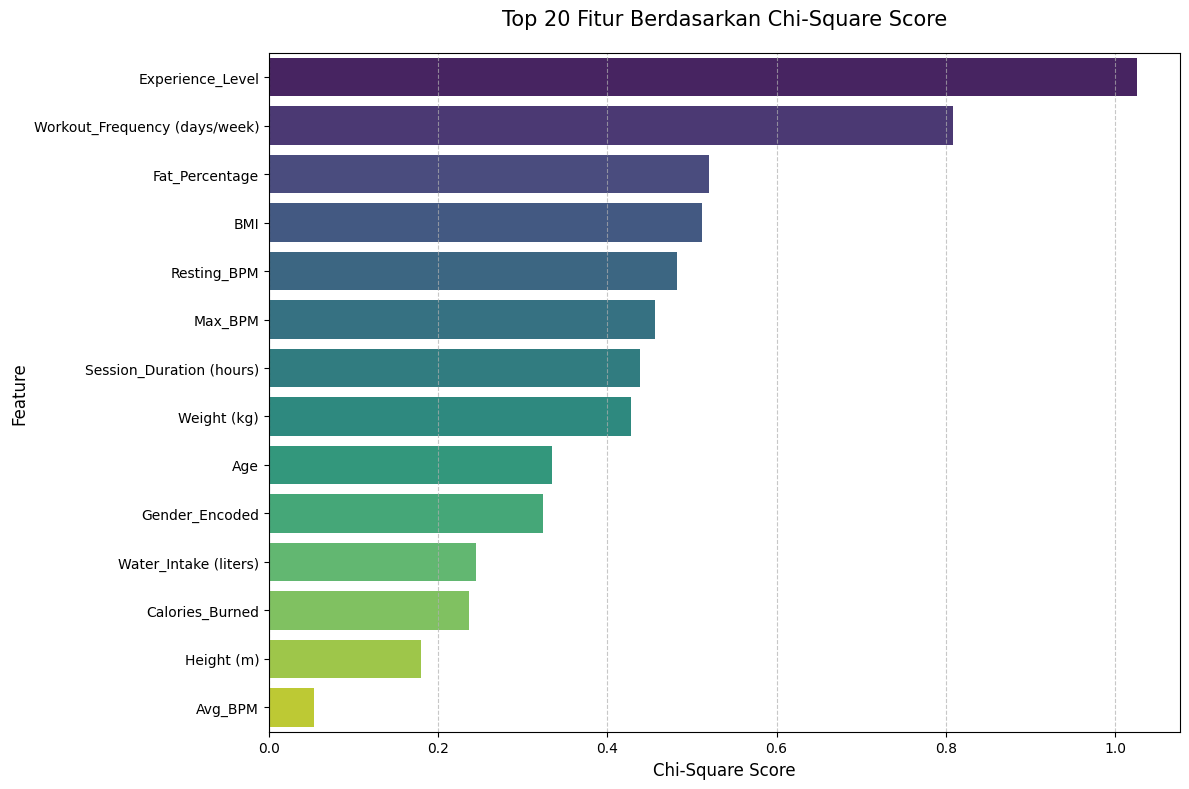

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Opsional: Mengambil hanya N fitur teratas agar grafik tidak terlalu penuh ---
# Misalnya kita hanya ingin melihat 20 fitur terbaik
top_n = 20
data_to_plot = chi2_scores.head(top_n)

# --- Mulai Plotting ---
plt.figure(figsize=(12, 8)) # Mengatur ukuran gambar

# Membuat barplot horizontal
# x = Nilai Score, y = Nama Feature
sns.barplot(
    data=data_to_plot,
    x='Chi2_Score',
    y='Feature',
    palette='viridis' # Pilihan warna: 'viridis', 'magma', 'coolwarm', dll
)

# Menambahkan judul dan label
plt.title(f'Top {top_n} Fitur Berdasarkan Chi-Square Score', fontsize=15, pad=20)
plt.xlabel('Chi-Square Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)

# Menambahkan grid tipis di belakang untuk memudahkan pembacaan nilai
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout() # Agar layout rapi dan tidak terpotong
plt.show()

# Plot


In [49]:
df_correlation_results = results_df.copy()
df_correlation_results["Feature Selection Method"] = "Filter - Correlation"
print("df_correlation_results head:")
print(df_correlation_results.head())

df_correlation_results head:
                 Model  Accuracy Feature Selection Method
0  Logistic Regression     28.34     Filter - Correlation
1                  KNN     26.20     Filter - Correlation
2        Decision Tree     22.99     Filter - Correlation
3        Random Forest     22.99     Filter - Correlation


In [41]:
import pandas as pd

backward_elimination_data = {
    "Model": ["KNN", "Random Forest", "Decision Tree", "Logistic Regression"],
    "Accuracy": [27.27, 27.27, 26.20, 25.67]
}
df_backward_results = pd.DataFrame(backward_elimination_data)
df_backward_results["Feature Selection Method"] = "Wrapper - Backward Elimination"
print("df_backward_results head:")
print(df_backward_results.head())

df_backward_results head:
                 Model  Accuracy        Feature Selection Method
0                  KNN     27.27  Wrapper - Backward Elimination
1        Random Forest     27.27  Wrapper - Backward Elimination
2        Decision Tree     26.20  Wrapper - Backward Elimination
3  Logistic Regression     25.67  Wrapper - Backward Elimination


In [42]:
rfe_data = {
    "Model": ["Random Forest", "Logistic Regression", "Decision Tree", "KNN"],
    "Accuracy": [23.53, 22.99, 21.39, 20.86]
}
df_rfe_results = pd.DataFrame(rfe_data)
df_rfe_results["Feature Selection Method"] = "Wrapper - RFE"
print("df_rfe_results head:")
print(df_rfe_results.head())

df_rfe_results head:
                 Model  Accuracy Feature Selection Method
0        Random Forest     23.53            Wrapper - RFE
1  Logistic Regression     22.99            Wrapper - RFE
2        Decision Tree     21.39            Wrapper - RFE
3                  KNN     20.86            Wrapper - RFE


In [43]:
ridge_data = {
    "Model": ["Logistic Regression", "Decision Tree", "KNN", "Random Forest"],
    "Accuracy": [28.34, 26.74, 24.06, 20.86]
}
df_ridge_results = pd.DataFrame(ridge_data)
df_ridge_results["Feature Selection Method"] = "Embedded - Ridge"
print("df_ridge_results head:")
print(df_ridge_results.head())

df_ridge_results head:
                 Model  Accuracy Feature Selection Method
0  Logistic Regression     28.34         Embedded - Ridge
1        Decision Tree     26.74         Embedded - Ridge
2                  KNN     24.06         Embedded - Ridge
3        Random Forest     20.86         Embedded - Ridge


**Reasoning**:
I need to store the model performance comparison from the 'Lasso' method (cell `wyYDlMrwqS1D`). I will manually create a DataFrame based on the `standard_output` from that cell and add the corresponding 'Feature Selection Method' column.



In [44]:
lasso_data = {
    "Model": ["Logistic Regression", "KNN", "Decision Tree", "Random Forest"],
    "Accuracy": [28.34, 26.20, 22.99, 22.99]
}
df_lasso_results = pd.DataFrame(lasso_data)
df_lasso_results["Feature Selection Method"] = "Embedded - Lasso"
print("df_lasso_results head:")
print(df_lasso_results.head())

df_lasso_results head:
                 Model  Accuracy Feature Selection Method
0  Logistic Regression     28.34         Embedded - Lasso
1                  KNN     26.20         Embedded - Lasso
2        Decision Tree     22.99         Embedded - Lasso
3        Random Forest     22.99         Embedded - Lasso


In [57]:
all_results_df = pd.concat([
    df_correlation_results,
    df_backward_results,
    df_rfe_results,
    df_ridge_results,
    df_lasso_results
]).reset_index(drop=True)

print("Combined Model Performance (all methods):")
print(all_results_df)
print("\nCombined Model Performance (tail for verification):")
print(all_results_df)

Combined Model Performance (all methods):
                  Model  Accuracy        Feature Selection Method
0   Logistic Regression     28.34            Filter - Correlation
1                   KNN     26.20            Filter - Correlation
2         Decision Tree     22.99            Filter - Correlation
3         Random Forest     22.99            Filter - Correlation
4                   KNN     27.27  Wrapper - Backward Elimination
5         Random Forest     27.27  Wrapper - Backward Elimination
6         Decision Tree     26.20  Wrapper - Backward Elimination
7   Logistic Regression     25.67  Wrapper - Backward Elimination
8         Random Forest     23.53                   Wrapper - RFE
9   Logistic Regression     22.99                   Wrapper - RFE
10        Decision Tree     21.39                   Wrapper - RFE
11                  KNN     20.86                   Wrapper - RFE
12  Logistic Regression     28.34                Embedded - Ridge
13        Decision Tree     26.74 

Rata-rata Akurasi per Model di Seluruh Metode Seleksi Fitur:
                 Model  Accuracy
2  Logistic Regression    26.736
1                  KNN    24.918
0        Decision Tree    24.062
3        Random Forest    23.528


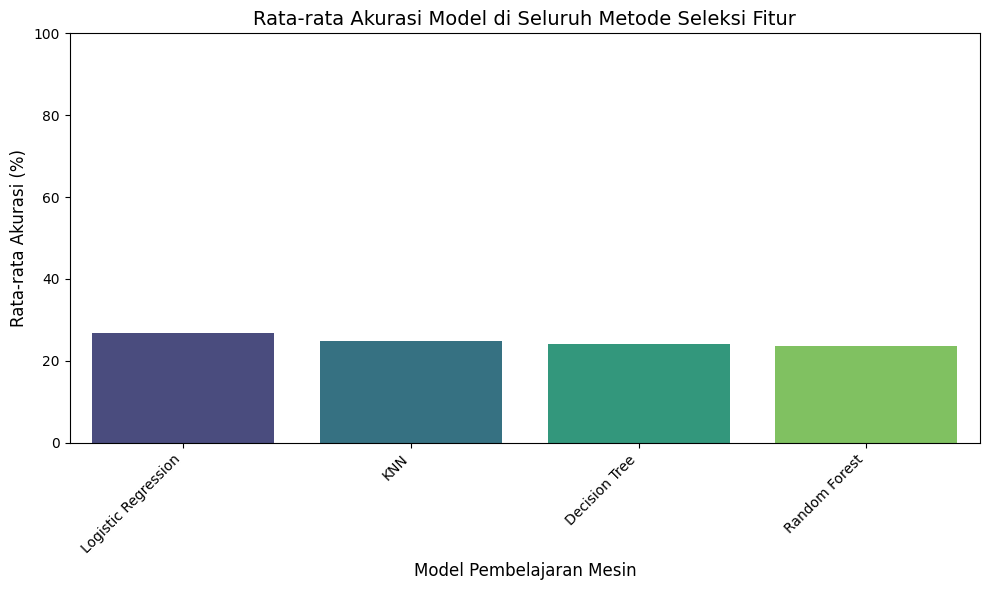

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

average_accuracy_per_model = all_results_df.groupby('Model')['Accuracy'].mean().reset_index()

average_accuracy_per_model = average_accuracy_per_model.sort_values(by='Accuracy', ascending=False)

print("Rata-rata Akurasi per Model di Seluruh Metode Seleksi Fitur:")
print(average_accuracy_per_model)

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', hue='Model', data=average_accuracy_per_model, palette='viridis', legend=False)
plt.title('Rata-rata Akurasi Model di Seluruh Metode Seleksi Fitur', fontsize=14)
plt.xlabel('Model Pembelajaran Mesin', fontsize=12)
plt.ylabel('Rata-rata Akurasi (%)', fontsize=12)
plt.ylim(0, 100)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipython-input-3760853608.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Accuracy", data=subset_df, palette="viridis")


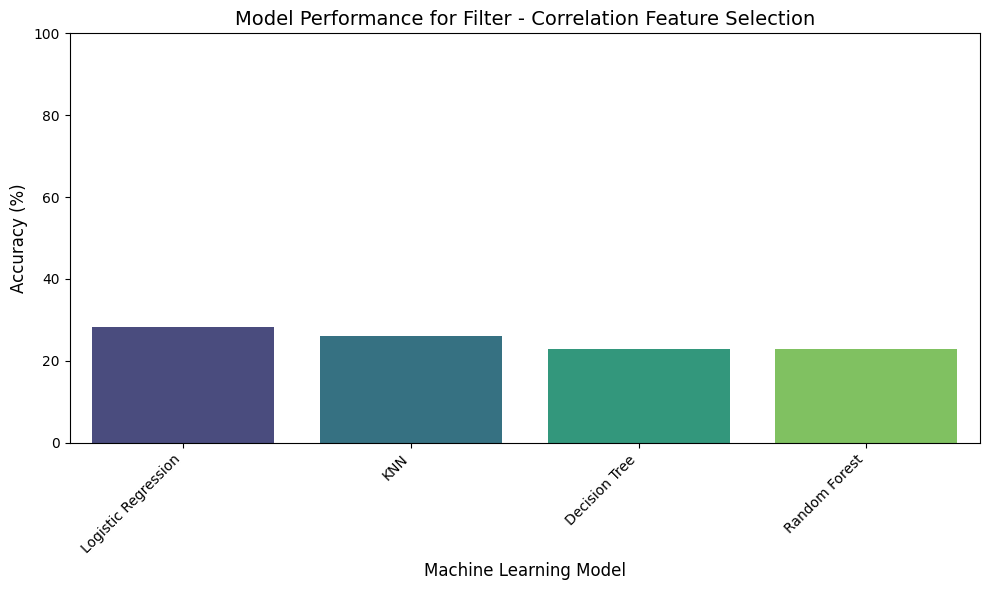

/tmp/ipython-input-3760853608.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Accuracy", data=subset_df, palette="viridis")


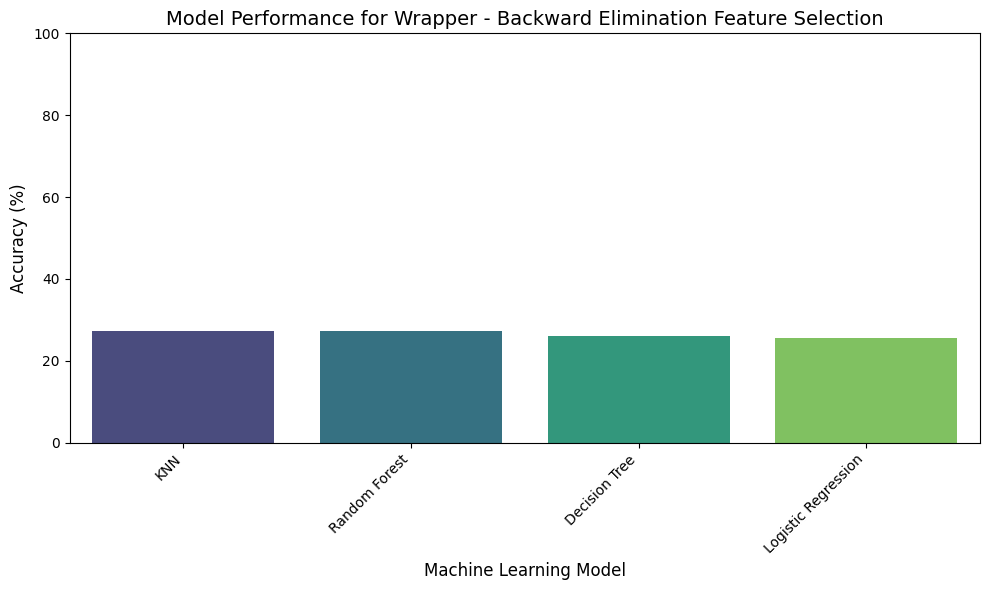

/tmp/ipython-input-3760853608.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Accuracy", data=subset_df, palette="viridis")


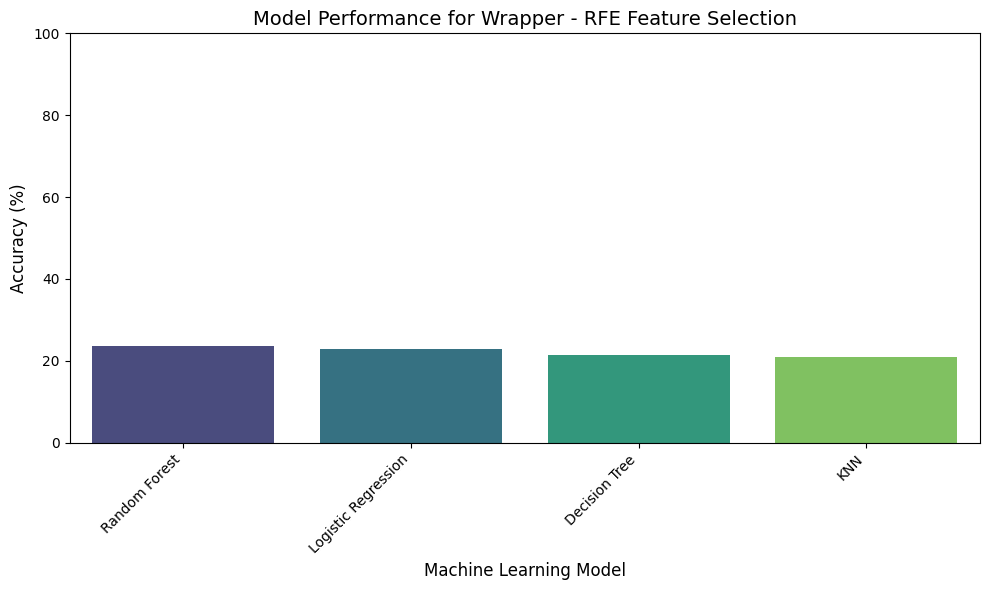

/tmp/ipython-input-3760853608.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Accuracy", data=subset_df, palette="viridis")


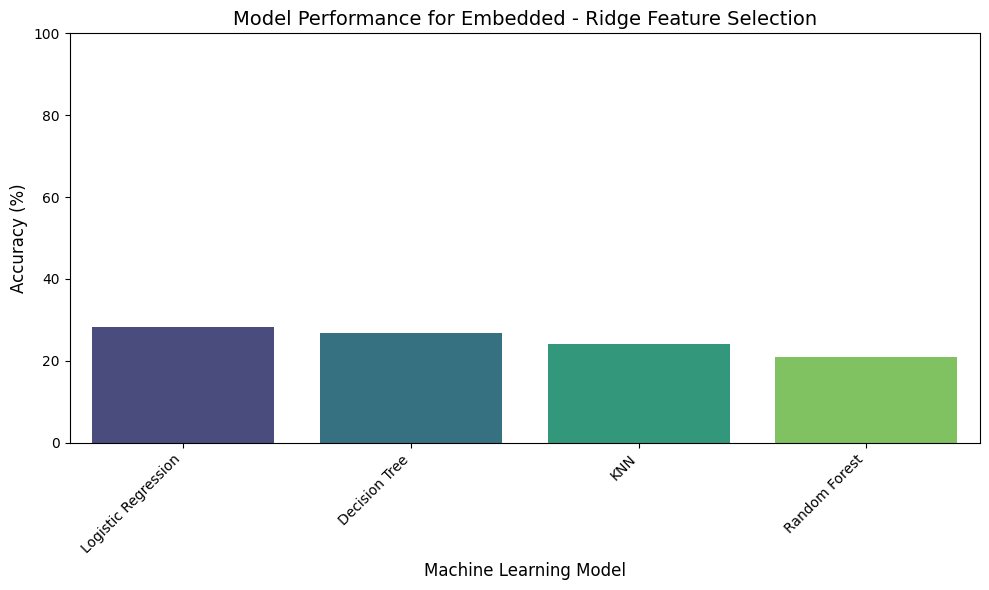

/tmp/ipython-input-3760853608.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Accuracy", data=subset_df, palette="viridis")


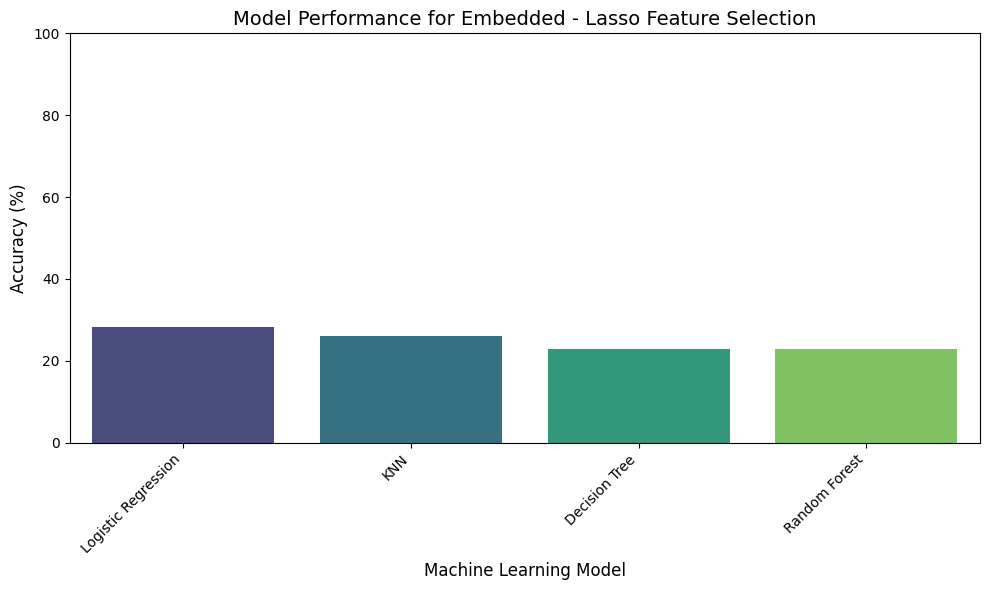

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns


unique_methods = all_results_df["Feature Selection Method"].unique()


for method in unique_methods:
    subset_df = all_results_df[all_results_df["Feature Selection Method"] == method].sort_values(by="Accuracy", ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x="Model", y="Accuracy", data=subset_df, palette="viridis")
    plt.title(f"Model Performance for {method} Feature Selection", fontsize=14)
    plt.xlabel("Machine Learning Model", fontsize=12)
    plt.ylabel("Accuracy (%)", fontsize=12)
    plt.ylim(0, 100)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


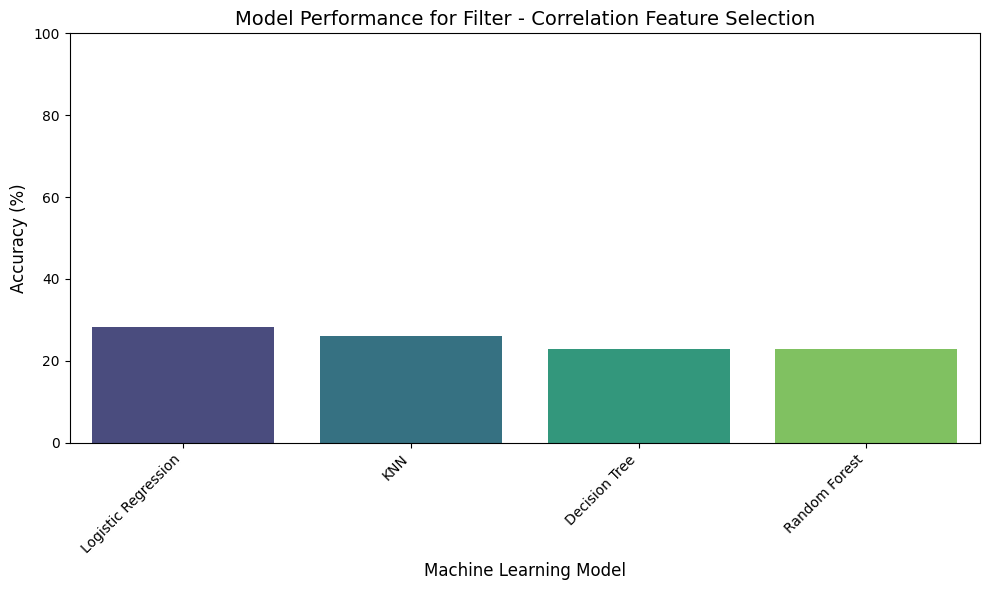

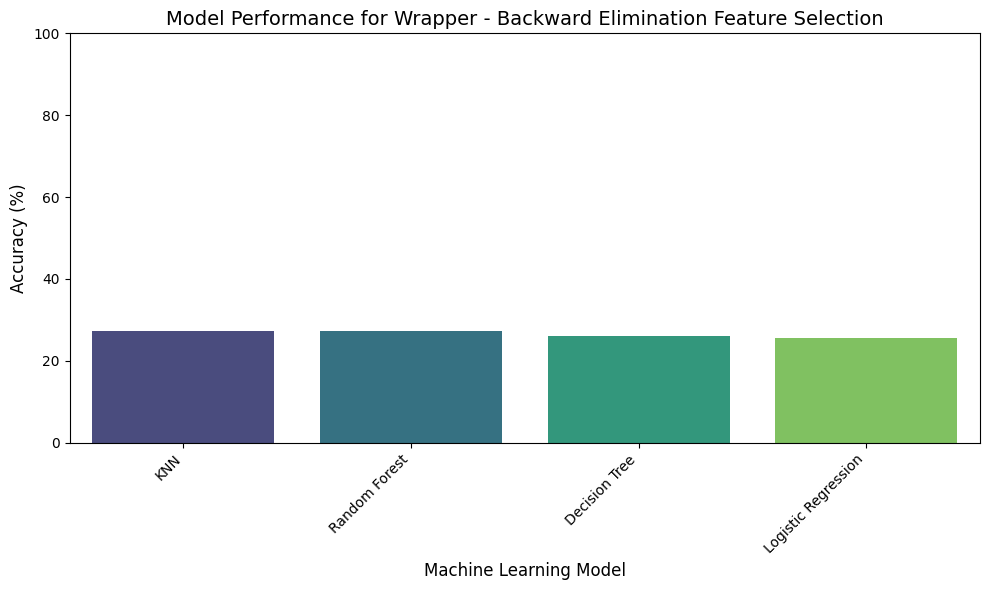

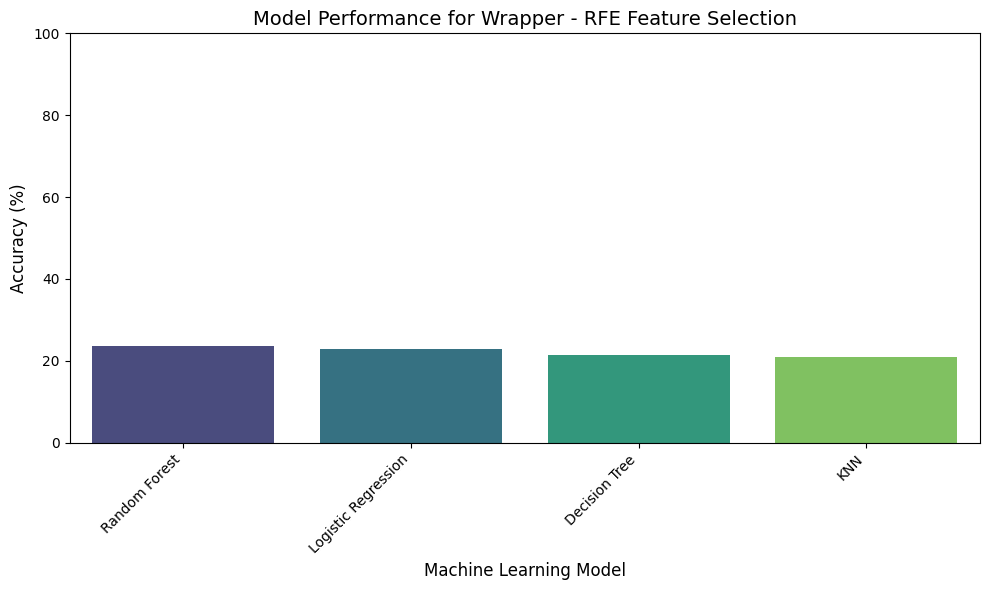

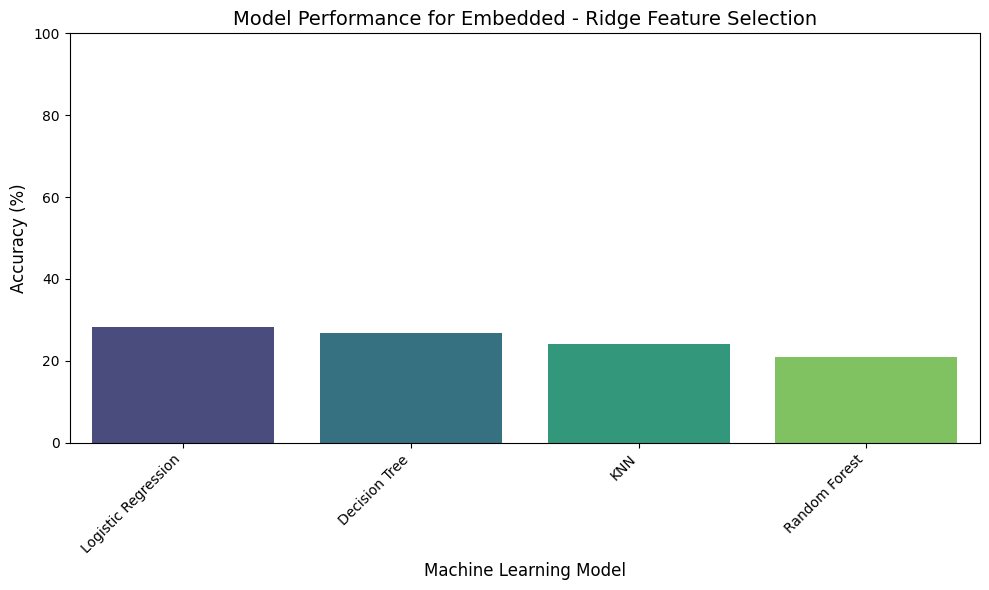

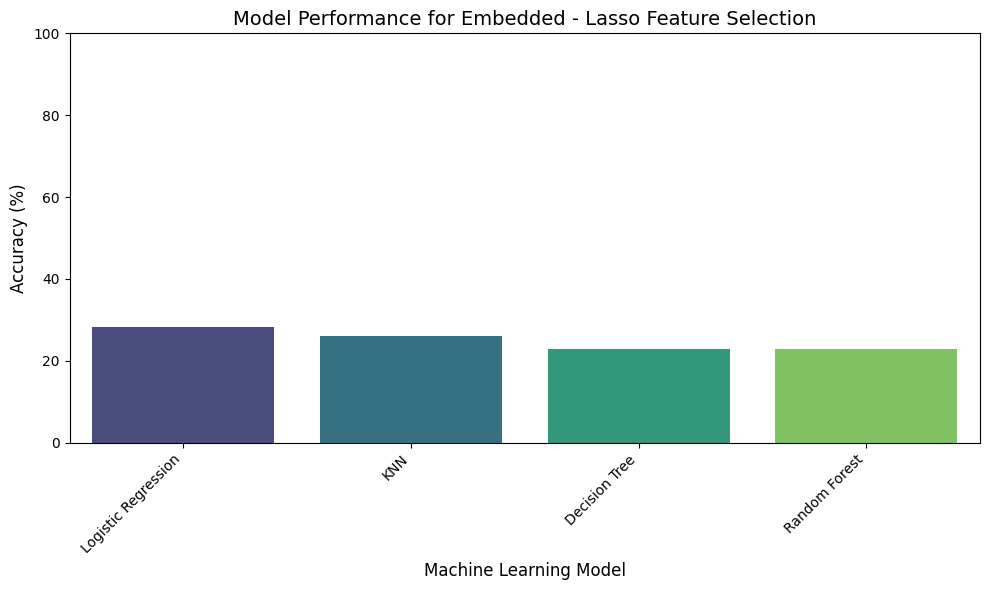

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

unique_methods = all_results_df["Feature Selection Method"].unique()

for method in unique_methods:
    subset_df = all_results_df[all_results_df["Feature Selection Method"] == method].sort_values(by="Accuracy", ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x="Model", y="Accuracy", hue="Model", data=subset_df, palette="viridis", legend=False)
    plt.title(f"Model Performance for {method} Feature Selection", fontsize=14)
    plt.xlabel("Machine Learning Model", fontsize=12)
    plt.ylabel("Accuracy (%)", fontsize=12)
    plt.ylim(0, 100)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


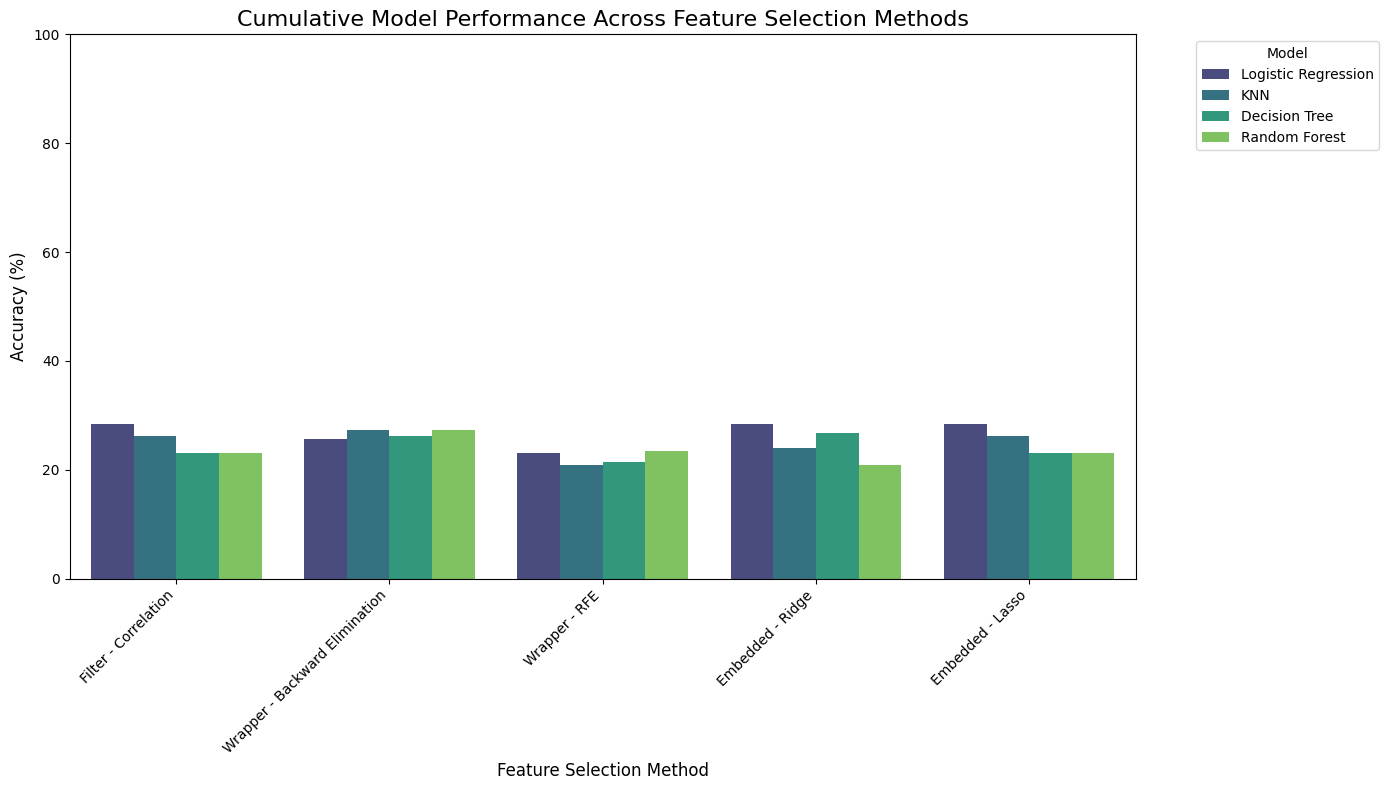

In [48]:
plt.figure(figsize=(14, 8))
sns.barplot(
    x="Feature Selection Method",
    y="Accuracy",
    hue="Model",
    data=all_results_df,
    palette="viridis"
)
plt.title("Cumulative Model Performance Across Feature Selection Methods", fontsize=16)
plt.xlabel("Feature Selection Method", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.ylim(0, 100)
plt.xticks(rotation=45, ha='right')
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
